# 原型网络 Few-Shot 分类教学 Notebook

本 Notebook 以 `Indian Pines` 为例，使用 **Prototypical Networks** 进行少样本高光谱图像分类。

核心思想：学一个好的嵌入空间，使得每个类的原型（支持集嵌入的均值）可以通过欧氏距离分类查询样本。

## 本 Notebook 做什么

1. 读取 Indian Pines 数据与标签
2. PCA 降维 + patch 提取
3. 实现 Episodic Sampler（N-way K-shot 采样）
4. 实现原型计算与距离分类
5. 训练原型网络
6. 评测不同 K-shot 的精度

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cpu")
print("device =", device)

class_names = [
    "Alfalfa", "Corn-notill", "Corn-mintill", "Corn",
    "Grass-pasture", "Grass-trees", "Grass-pasture-mowed", "Hay-windrowed",
    "Oats", "Soybean-notill", "Soybean-mintill", "Soybean-clean",
    "Wheat", "Woods", "Buildings-Grass-Trees-Drives", "Stone-Steel-Towers",
]

device = cpu


## 1. 读取数据

与前面章节相同的 Indian Pines corrected 数据集（145×145×200）。

In [2]:
dataset_dir = Path("dataset")
cube = loadmat(dataset_dir / "Indian_pines_corrected.mat")["indian_pines_corrected"].astype(np.float32)
gt = loadmat(dataset_dir / "Indian_pines_gt.mat")["indian_pines_gt"].astype(np.int64)
print("cube:", cube.shape, "| gt:", gt.shape, "| classes:", gt.max())

cube: (145, 145, 200) | gt: (145, 145) | classes: 16


## 2. PCA 降维 + patch 提取

与第 6 章 2D CNN 相同的预处理管线（PCA-12 + 9×9 patch + StandardScaler）。

In [3]:
h, w, bands = cube.shape
flat = cube.reshape(-1, bands)
pca = PCA(n_components=12, whiten=True)
reduced = pca.fit_transform(flat).astype(np.float32).reshape(h, w, -1)
print("reduced:", reduced.shape, "| explained variance:", f"{pca.explained_variance_ratio_.sum():.2%}")

# StandardScaler on train pixels only
from sklearn.model_selection import train_test_split
positions = np.argwhere(gt > 0)
labels_all = (gt[gt > 0] - 1).astype(np.int64)
X_train_pos, X_temp_pos, y_train, y_temp = train_test_split(
    positions, labels_all, train_size=0.1, stratify=labels_all, random_state=SEED)
val_ratio = 0.1 / 0.9
X_val_pos, X_test_pos, y_val, y_test = train_test_split(
    X_temp_pos, y_temp, train_size=val_ratio, stratify=y_temp, random_state=SEED)

scaler = StandardScaler()
scaler.fit(reduced[X_train_pos[:, 0], X_train_pos[:, 1]])
reduced_scaled = scaler.transform(reduced.reshape(-1, 12)).astype(np.float32).reshape(h, w, 12)
print("train:", len(y_train), "val:", len(y_val), "test:", len(y_test))

reduced: (145, 145, 12) | explained variance: 97.43%
train: 1024 val: 1025 test: 8200


In [4]:
PAD = 4  # (9-1)/2
padded = np.pad(reduced_scaled, ((PAD, PAD), (PAD, PAD), (0, 0)), mode="constant")

def extract(pos):
    patches = np.zeros((len(pos), 9, 9, 12), dtype=np.float32)
    for k, (r, c) in enumerate(pos):
        patches[k] = padded[r: r + 9, c: c + 9]
    return patches

train_patches = extract(X_train_pos)
test_patches = extract(X_test_pos)
print("train patches:", train_patches.shape, "| test patches:", test_patches.shape)

train patches:

 (1024, 9, 9, 12) | test patches: (8200, 9, 9, 12)


## 3. Episodic Sampler

每个 episode 随机抽 N 个类，每类 K 个支持样本 + Q 个查询样本。

- **N-way**：每个 episode 有多少个类
- **K-shot**：每个类多少个支持样本
- **Q-query**：每个类多少个查询样本

In [5]:
class EpisodicSampler:
    def __init__(self, patches, labels, rng):
        self.patches = patches
        self.labels = labels
        self.rng = rng
        self.class_indices = {c: np.where(labels == c)[0] for c in range(labels.max() + 1)}

    def sample_episode(self, n_way, k_shot, q_query):
        available = [c for c in self.class_indices
                     if len(self.class_indices[c]) >= k_shot + q_query]
        classes = self.rng.choice(available, size=min(n_way, len(available)), replace=False)
        sx, sy, qx, qy = [], [], [], []
        for new_label, c in enumerate(classes):
            idx = self.rng.choice(self.class_indices[c], size=k_shot + q_query, replace=False)
            sx.append(self.patches[idx[:k_shot]])
            sy.append(np.full(k_shot, new_label))
            qx.append(self.patches[idx[k_shot:]])
            qy.append(np.full(q_query, new_label))
        return (np.concatenate(sx), np.concatenate(sy),
                np.concatenate(qx), np.concatenate(qy))

rng = np.random.default_rng(SEED)
train_sampler = EpisodicSampler(train_patches, y_train, rng)
test_sampler = EpisodicSampler(test_patches, y_test, rng)

# 看一个 episode 的形状
sx, sy, qx, qy = train_sampler.sample_episode(n_way=5, k_shot=5, q_query=15)
print(f"support: {sx.shape}, labels: {sy.shape}")
print(f"query:   {qx.shape}, labels: {qy.shape}")

support: (25, 9, 9, 12), labels: (25,)
query:   (75, 9, 9, 12), labels: (75,)


## 4. 编码器 + 原型分类

编码器复用 2D CNN 的 `features` 部分（128 维嵌入），去掉分类头。

**原型计算**：支持集嵌入的类均值。
**距离分类**：查询样本到各原型的负欧氏距离 → softmax。

In [6]:
import sys
sys.path.insert(0, str(Path("scripts")))
from train_2d_cnn import SpectralSpatialCNN2D

class PrototypicalEncoder(nn.Module):
    '''2D CNN features → 128-d embedding (no classifier head).'''
    def __init__(self, in_channels=12):
        super().__init__()
        self.features = SpectralSpatialCNN2D(in_channels, num_classes=16).features
    def forward(self, x):
        return self.features(x).flatten(1)  # (B, 128)

encoder = PrototypicalEncoder(12).to(device)
print("encoder params:", sum(p.numel() for p in encoder.parameters()))

encoder params: 96288


In [7]:
def prototypical_loss(support_emb, support_y, query_emb, query_y, n_way):
    '''Compute prototypes from support set, classify queries by distance.'''
    prototypes = torch.stack([
        support_emb[support_y == c].mean(dim=0) for c in range(n_way)
    ])  # (n_way, D)
    distances = torch.cdist(query_emb, prototypes)  # (M, n_way)
    log_p_y = F.log_softmax(-distances, dim=1)  # closer → higher prob
    return F.nll_loss(log_p_y, query_y)

@torch.no_grad()
def evaluate(sampler, n_episodes, n_way, k_shot, q_query):
    correct = total = 0
    for _ in range(n_episodes):
        sx, sy, qx, qy = sampler.sample_episode(n_way, k_shot, q_query)
        sx = torch.from_numpy(sx).permute(0, 3, 1, 2)
        qx = torch.from_numpy(qx).permute(0, 3, 1, 2)
        sy_t = torch.from_numpy(sy)
        qy_t = torch.from_numpy(qy)
        s_emb = encoder(sx).flatten(1)
        q_emb = encoder(qx).flatten(1)
        protos = torch.stack([s_emb[sy_t == c].mean(0) for c in range(n_way)])
        dists = torch.cdist(q_emb, protos)
        correct += (dists.argmin(1) == qy_t).sum().item()
        total += len(qy_t)
    return correct / total if total else 0.0

# before training
acc0 = evaluate(test_sampler, 20, 5, 5, 15)
print(f"before training: 5-way 5-shot acc = {acc0:.4f}")

before training: 5-way 5-shot acc = 0.7827

## 5. 训练（Episodic Training）

每个 episode 的训练流程：采样 → 编码 → 原型 → 距离分类 → 损失 → 反向传播。

In [8]:
N_WAY = 5
K_SHOT = 5
Q_QUERY = 15
EPISODES = 200
LR = 1e-4

optimizer = torch.optim.Adam(encoder.parameters(), lr=LR)
history = {"loss": [], "val_acc": []}

for ep in range(1, EPISODES + 1):
    encoder.train()
    sx, sy, qx, qy = train_sampler.sample_episode(N_WAY, K_SHOT, Q_QUERY)
    sx = torch.from_numpy(sx).permute(0, 3, 1, 2)
    qx = torch.from_numpy(qx).permute(0, 3, 1, 2)
    sy_t = torch.from_numpy(sy)
    qy_t = torch.from_numpy(qy)

    optimizer.zero_grad()
    s_emb = encoder(sx).flatten(1)
    q_emb = encoder(qx).flatten(1)
    loss = prototypical_loss(s_emb, sy_t, q_emb, qy_t, N_WAY)
    loss.backward()
    optimizer.step()
    history["loss"].append(loss.item())

    if ep % 50 == 0 or ep == 1:
        encoder.eval()
        acc = evaluate(test_sampler, 20, N_WAY, K_SHOT, Q_QUERY)
        history["val_acc"].append(acc)
        print(f"episode {ep}/{EPISODES}  loss={loss.item():.4f}  test_acc={acc:.4f}")

episode 1/200  loss=0.8642  test_acc=0.8187


episode 50/200  loss=0.2509  test_acc=0.8453


episode 100/200  loss=0.2908  test_acc=0.9033


episode 150/200  loss=0.1427  test_acc=0.8513


episode 200/200  loss=0.4439  test_acc=0.8967


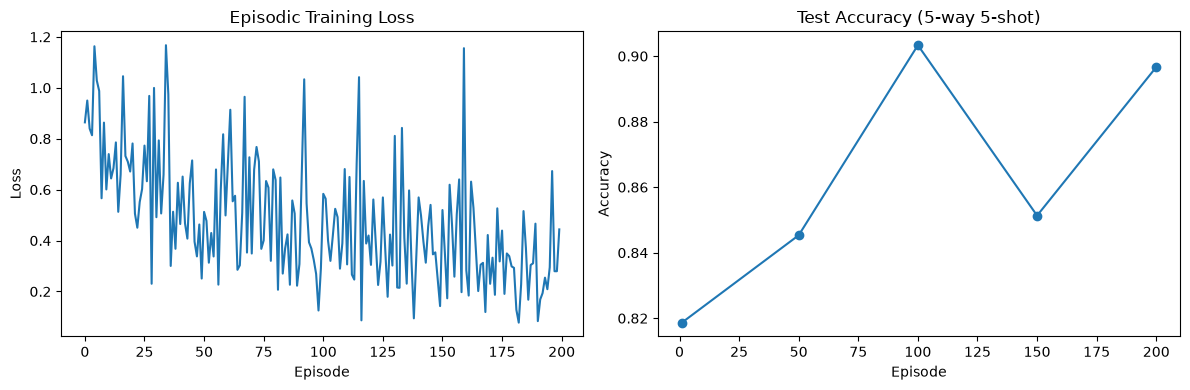

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["loss"])
axes[0].set_title("Episodic Training Loss")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Loss")
eval_eps = [1] + list(range(50, EPISODES + 1, 50))
axes[1].plot(eval_eps[:len(history["val_acc"])], history["val_acc"], marker="o")
axes[1].set_title("Test Accuracy (5-way 5-shot)")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

## 6. K-shot 对比（1 / 5 / 10-shot）

K 的本质是**原型估计的置信度**：K 越大，原型均值越稳定。

1-shot: 0.8248


5-shot: 0.8955


10-shot: 0.8940


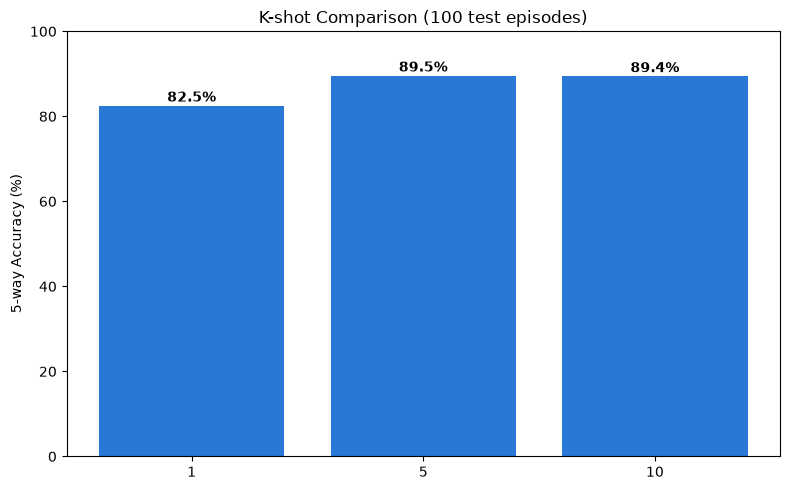

In [10]:
encoder.eval()
results = {}
for k in [1, 5, 10]:
    acc = evaluate(test_sampler, 100, 5, k, 15)
    results[k] = acc
    print(f"{k}-shot: {acc:.4f}")

plt.bar([str(k) for k in results], [v * 100 for v in results.values()], color="#2a78d6")
plt.ylabel("5-way Accuracy (%)")
plt.title("K-shot Comparison (100 test episodes)")
plt.ylim(0, 100)
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v * 100 + 1, f"{v * 100:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. 全图原型分类图

用训练样本计算所有 16 类的原型，然后对整幅图的每个像元进行最近原型分类。

prototypes: (16, 128)


prediction map: (145, 145)


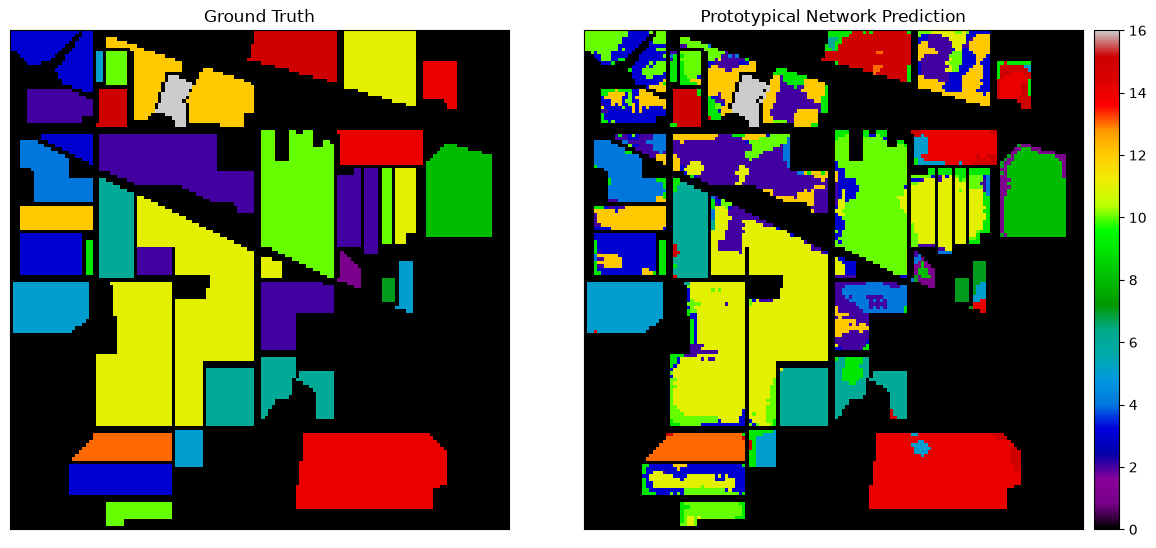

In [11]:
# 计算 16 类原型（用训练集嵌入均值）
encoder.eval()
train_embs = []
with torch.no_grad():
    for start in range(0, len(train_patches), 512):
        batch = torch.from_numpy(train_patches[start:start+512]).permute(0, 3, 1, 2)
        train_embs.append(encoder(batch).flatten(1).cpu().numpy())
train_embs = np.concatenate(train_embs)
all_prototypes = np.stack([train_embs[y_train == c].mean(0) for c in range(16)])
print("prototypes:", all_prototypes.shape)

# 全图像元 embedding + 最近原型分类
all_pos = np.argwhere(np.ones_like(gt, dtype=bool))
all_p = []
PAD = 4
padded_all = np.pad(reduced_scaled, ((PAD, PAD), (PAD, PAD), (0, 0)), mode="constant")
for k, (r, c) in enumerate(all_pos):
    all_p.append(padded[r:r+9, c:c+9])
all_p = np.array(all_p, dtype=np.float32)

all_embs = []
with torch.no_grad():
    for start in range(0, len(all_p), 512):
        batch = torch.from_numpy(all_p[start:start+512]).permute(0, 3, 1, 2)
        all_embs.append(encoder(batch).flatten(1).cpu().numpy())
all_embs = np.concatenate(all_embs)

from scipy.spatial.distance import cdist
dists = cdist(all_embs, all_prototypes)
pred_map = np.array([np.argmin(d) for d in dists]).reshape(145, 145) + 1
print("prediction map:", pred_map.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
axes[0].imshow(gt, cmap="nipy_spectral", vmin=0, vmax=16, interpolation="nearest")
axes[0].set_title("Ground Truth")
axes[0].set_xticks([]); axes[0].set_yticks([])
im = axes[1].imshow(pred_map * (gt > 0), cmap="nipy_spectral", vmin=0, vmax=16, interpolation="nearest")
axes[1].set_title("Prototypical Network Prediction")
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.02)
plt.tight_layout()
plt.show()

## 8. 小结

- **原型网络**用"类均值原型 + 欧氏距离"替代了传统的分类器层
- **Episodic training** 让模型学习"从 K 个样本区分类别"的元能力
- K-shot 曲线呈现边际递减：1→5 大幅提升，5→10 趋于平稳
- 嵌入空间的质量是 few-shot 成功的关键——好的嵌入空间使新类只需算原型即可分类